# Day 5 - Feature Engineering (Part 1)

Objective:
Create meaningful features from stock price data that can be used by machine learning models to predict future stock movements and assess risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
stock=pd.read_csv("../data/reliance_cleaned.csv",index_col=0,parse_dates=True)
stock.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-01-01,187.467316,189.460526,187.214203,189.291780,5849398
2014-01-02,184.556564,188.985922,183.523049,187.235265,6023632
2014-01-03,182.289169,184.208559,180.338142,183.839443,12833897
2014-01-06,180.327576,182.078233,179.283514,181.835666,13315857
2014-01-07,177.617279,181.382225,177.184888,180.253797,17311470


In [5]:
stock['Return']=stock['Close'].pct_change()
stock[['Close','Return']].head()

,Close,Return
Date,,
2014-01-01,187.467316,NaN
2014-01-02,184.556564,-0.015527
2014-01-03,182.289169,-0.012286
2014-01-06,180.327576,-0.010761
2014-01-07,177.617279,-0.015030


In [6]:
stock[['Close','Return']].tail()

,Close,Return
Date,,
2024-12-23,1211.834717,0.014104
2024-12-24,1212.280762,0.000368
2024-12-26,1206.133911,-0.005070
2024-12-27,1210.595459,0.003699
2024-12-30,1200.333984,-0.008476


In [10]:
stock['MA_5']=stock['Close'].rolling(window=5).mean()
stock[['Close', 'MA_5']].head(10)

,Close,MA_5
Date,,
2014-01-01,187.467316,NaN
2014-01-02,184.556564,NaN
2014-01-03,182.289169,NaN
2014-01-06,180.327576,NaN
2014-01-07,177.617279,182.451581
2014-01-08,179.083176,180.774753
2014-01-09,179.431168,179.749673
2014-01-10,181.002563,179.492352
2014-01-13,185.695557,180.565948


In [11]:
stock['MA_20']=stock['Close'].rolling(window=20).mean()
stock[['Close', 'MA_20']].head(25)

,Close,MA_20
Date,,
2014-01-01,187.467316,NaN
2014-01-02,184.556564,NaN
2014-01-03,182.289169,NaN
2014-01-06,180.327576,NaN
2014-01-07,177.617279,NaN
2014-01-08,179.083176,NaN
2014-01-09,179.431168,NaN
2014-01-10,181.002563,NaN
2014-01-13,185.695557,NaN


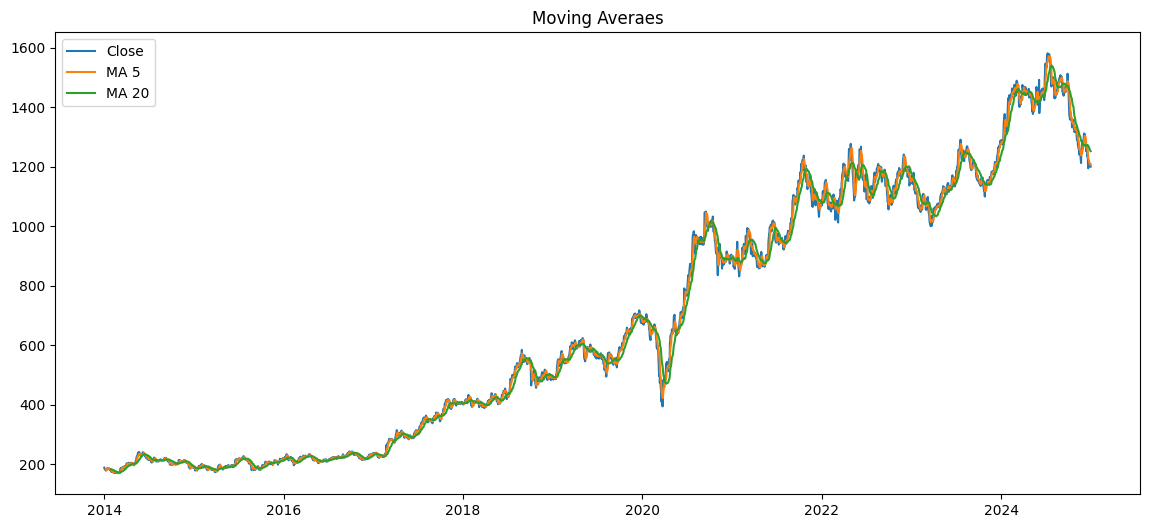

In [12]:
plt.figure(figsize=(14,6))

plt.plot(stock['Close'],label='Close')
plt.plot(stock['MA_5'],label='MA 5')
plt.plot(stock['MA_20'],label='MA 20')
plt.legend()
plt.title("Moving Averaes")

plt.show()



In [17]:
stock['Volatility_20']=stock['Return'].rolling(window=20).std()
stock[['Return','Volatility_20']].tail()

,Return,Volatility_20
Date,,
2024-12-23,0.014104,0.012267
2024-12-24,0.000368,0.012095
2024-12-26,-0.005070,0.012103
2024-12-27,0.003699,0.011698
2024-12-30,-0.008476,0.010903


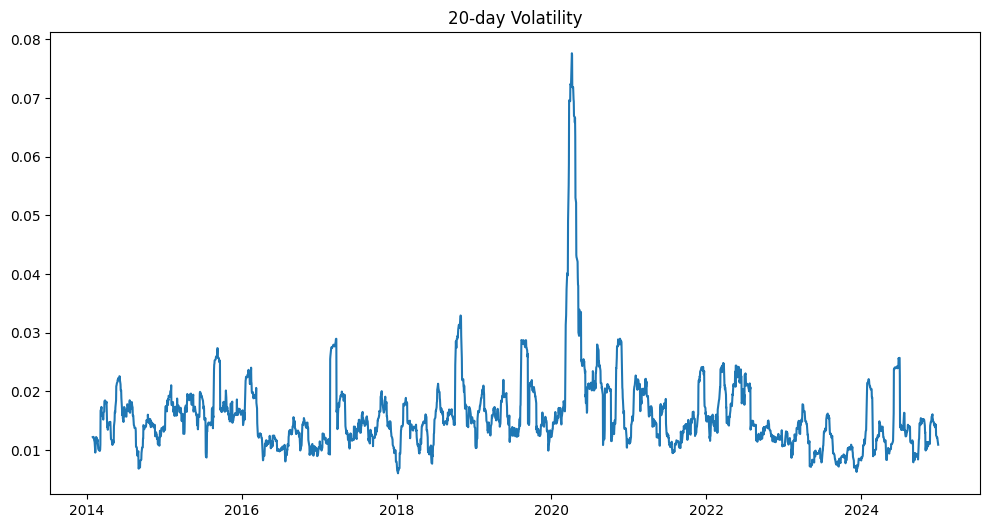

In [20]:
plt.figure(figsize=(12,6))
plt.plot(stock['Volatility_20'])
plt.title("20-day Volatility")
plt.show()

In [21]:
stock.to_csv("../data/reliance_features_v1.csv")